In [1]:
!pip install pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 8.4 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

In [3]:
import pm4py
import pandas as pd
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

In [4]:
# Import the log
log = xes_importer.apply('/content/drive/MyDrive/dataset/BPI Challenge 2017.xes')

# Verify
print(f"Successfully loaded {len(log)} traces.")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Successfully loaded 31509 traces.


In [5]:
log

[{'attributes': {'LoanGoal': 'Existing loan takeover', 'ApplicationType': 'New credit', 'concept:name': 'Application_652823628', 'RequestedAmount': 20000.0}, 'events': [{'Action': 'Created', 'org:resource': 'User_1', 'concept:name': 'A_Create Application', 'EventOrigin': 'Application', 'EventID': 'Application_652823628', 'lifecycle:transition': 'complete', 'time:timestamp': datetime.datetime(2016, 1, 1, 9, 51, 15, 304000, tzinfo=datetime.timezone.utc)}, '..', {'Action': 'Deleted', 'org:resource': 'User_115', 'concept:name': 'W_Validate application', 'EventOrigin': 'Workflow', 'EventID': 'Workitem_2067229931', 'lifecycle:transition': 'ate_abort', 'time:timestamp': datetime.datetime(2016, 1, 14, 15, 49, 11, 423000, tzinfo=datetime.timezone.utc)}]}, '....', {'attributes': {'LoanGoal': 'Home improvement', 'ApplicationType': 'New credit', 'concept:name': 'Application_1350494635', 'RequestedAmount': 20000.0}, 'events': [{'Action': 'Created', 'org:resource': 'User_1', 'concept:name': 'A_Creat

In [6]:
# Convert the event log to a pandas DataFrame
df_view = pm4py.convert_to_dataframe(log)

# Display the first 20 rows of the event log
df_view.head(20)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Obtained,User_17,W_Complete application,Workflow,Workitem_1875340971,start,2016-01-02 10:45:22.429000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Released,User_17,W_Complete application,Workflow,Workitem_1452291795,suspend,2016-01-02 10:49:28.816000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Created,User_52,O_Create Offer,Offer,Offer_148581083,complete,2016-01-02 11:29:03.994000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,20000.0,44.0,True,498.29,True,979.0,20000.0,NaN


In [7]:
# Get the variants from the log
from pm4py.algo.filtering.log.variants import variants_filter
variants = variants_filter.get_variants(log)

# Count and sort the variants by frequency
from collections import Counter
variants_count = Counter()
for v in variants:
    variants_count[v] += len(variants[v])

# Display the top most frequent variants (the "Class Log" variants)
top_variants = sorted(variants_count.items(), key=lambda x: x[1], reverse=True)[:50]

for i, (variant, count) in enumerate(top_variants):
    print(f"Variant {i+1} (Occurrences: {count}):")
    print(f" Sequence: {variant}\n")

Variant 1 (Occurrences: 1056):
 Sequence: ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_Complete application', 'A_Concept', 'W_Complete application', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'A_Complete', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'A_Cancelled', 'O_Cancelled', 'W_Call after offers')

Variant 2 (Occurrences: 1021):
 Sequence: ('A_Create Application', 'W_Complete application', 'W_Complete application', 'A_Concept', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'A_Complete', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'A_Cancelled', 'O_Cancelled', 'W_Call after offers')

Variant 3 (Occurrences: 734):
 Sequence: ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_C

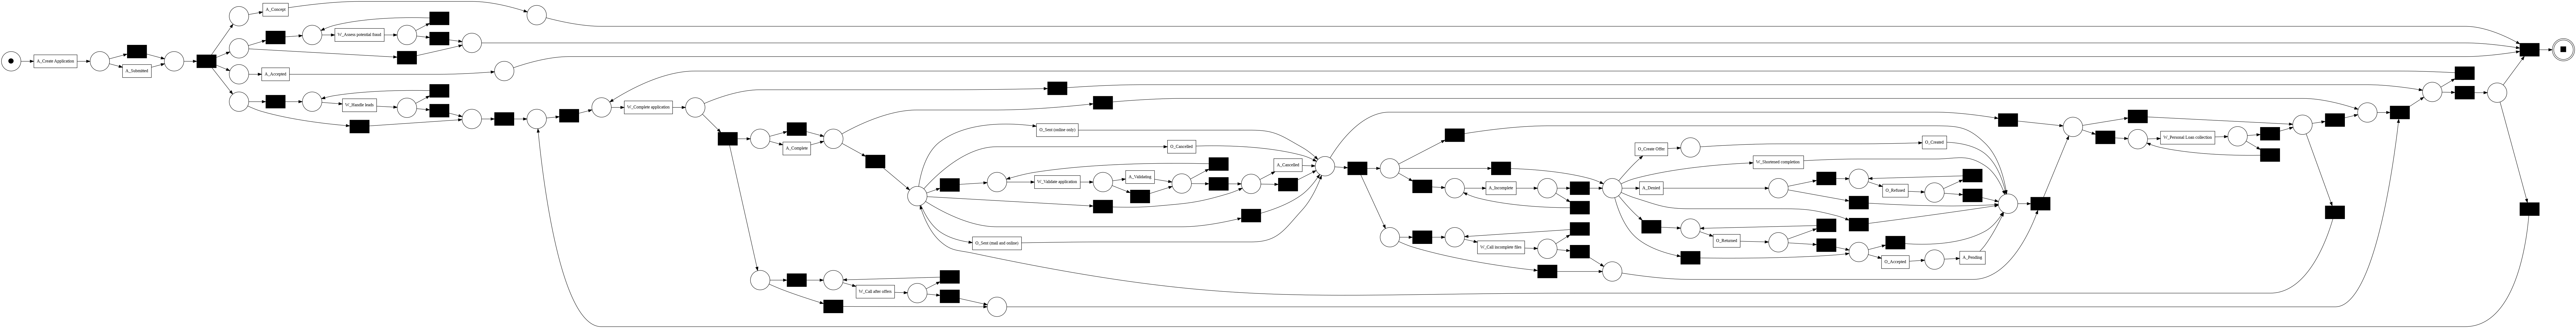

''

In [8]:
import pm4py
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

# Discover the Petri net from the log
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)

# visualization
gviz = pn_visualizer.apply(net, initial_marking, final_marking)

# Display the image
pn_visualizer.view(gviz)

# Save the image
pn_visualizer.save(gviz, "classical_petri_net.png")

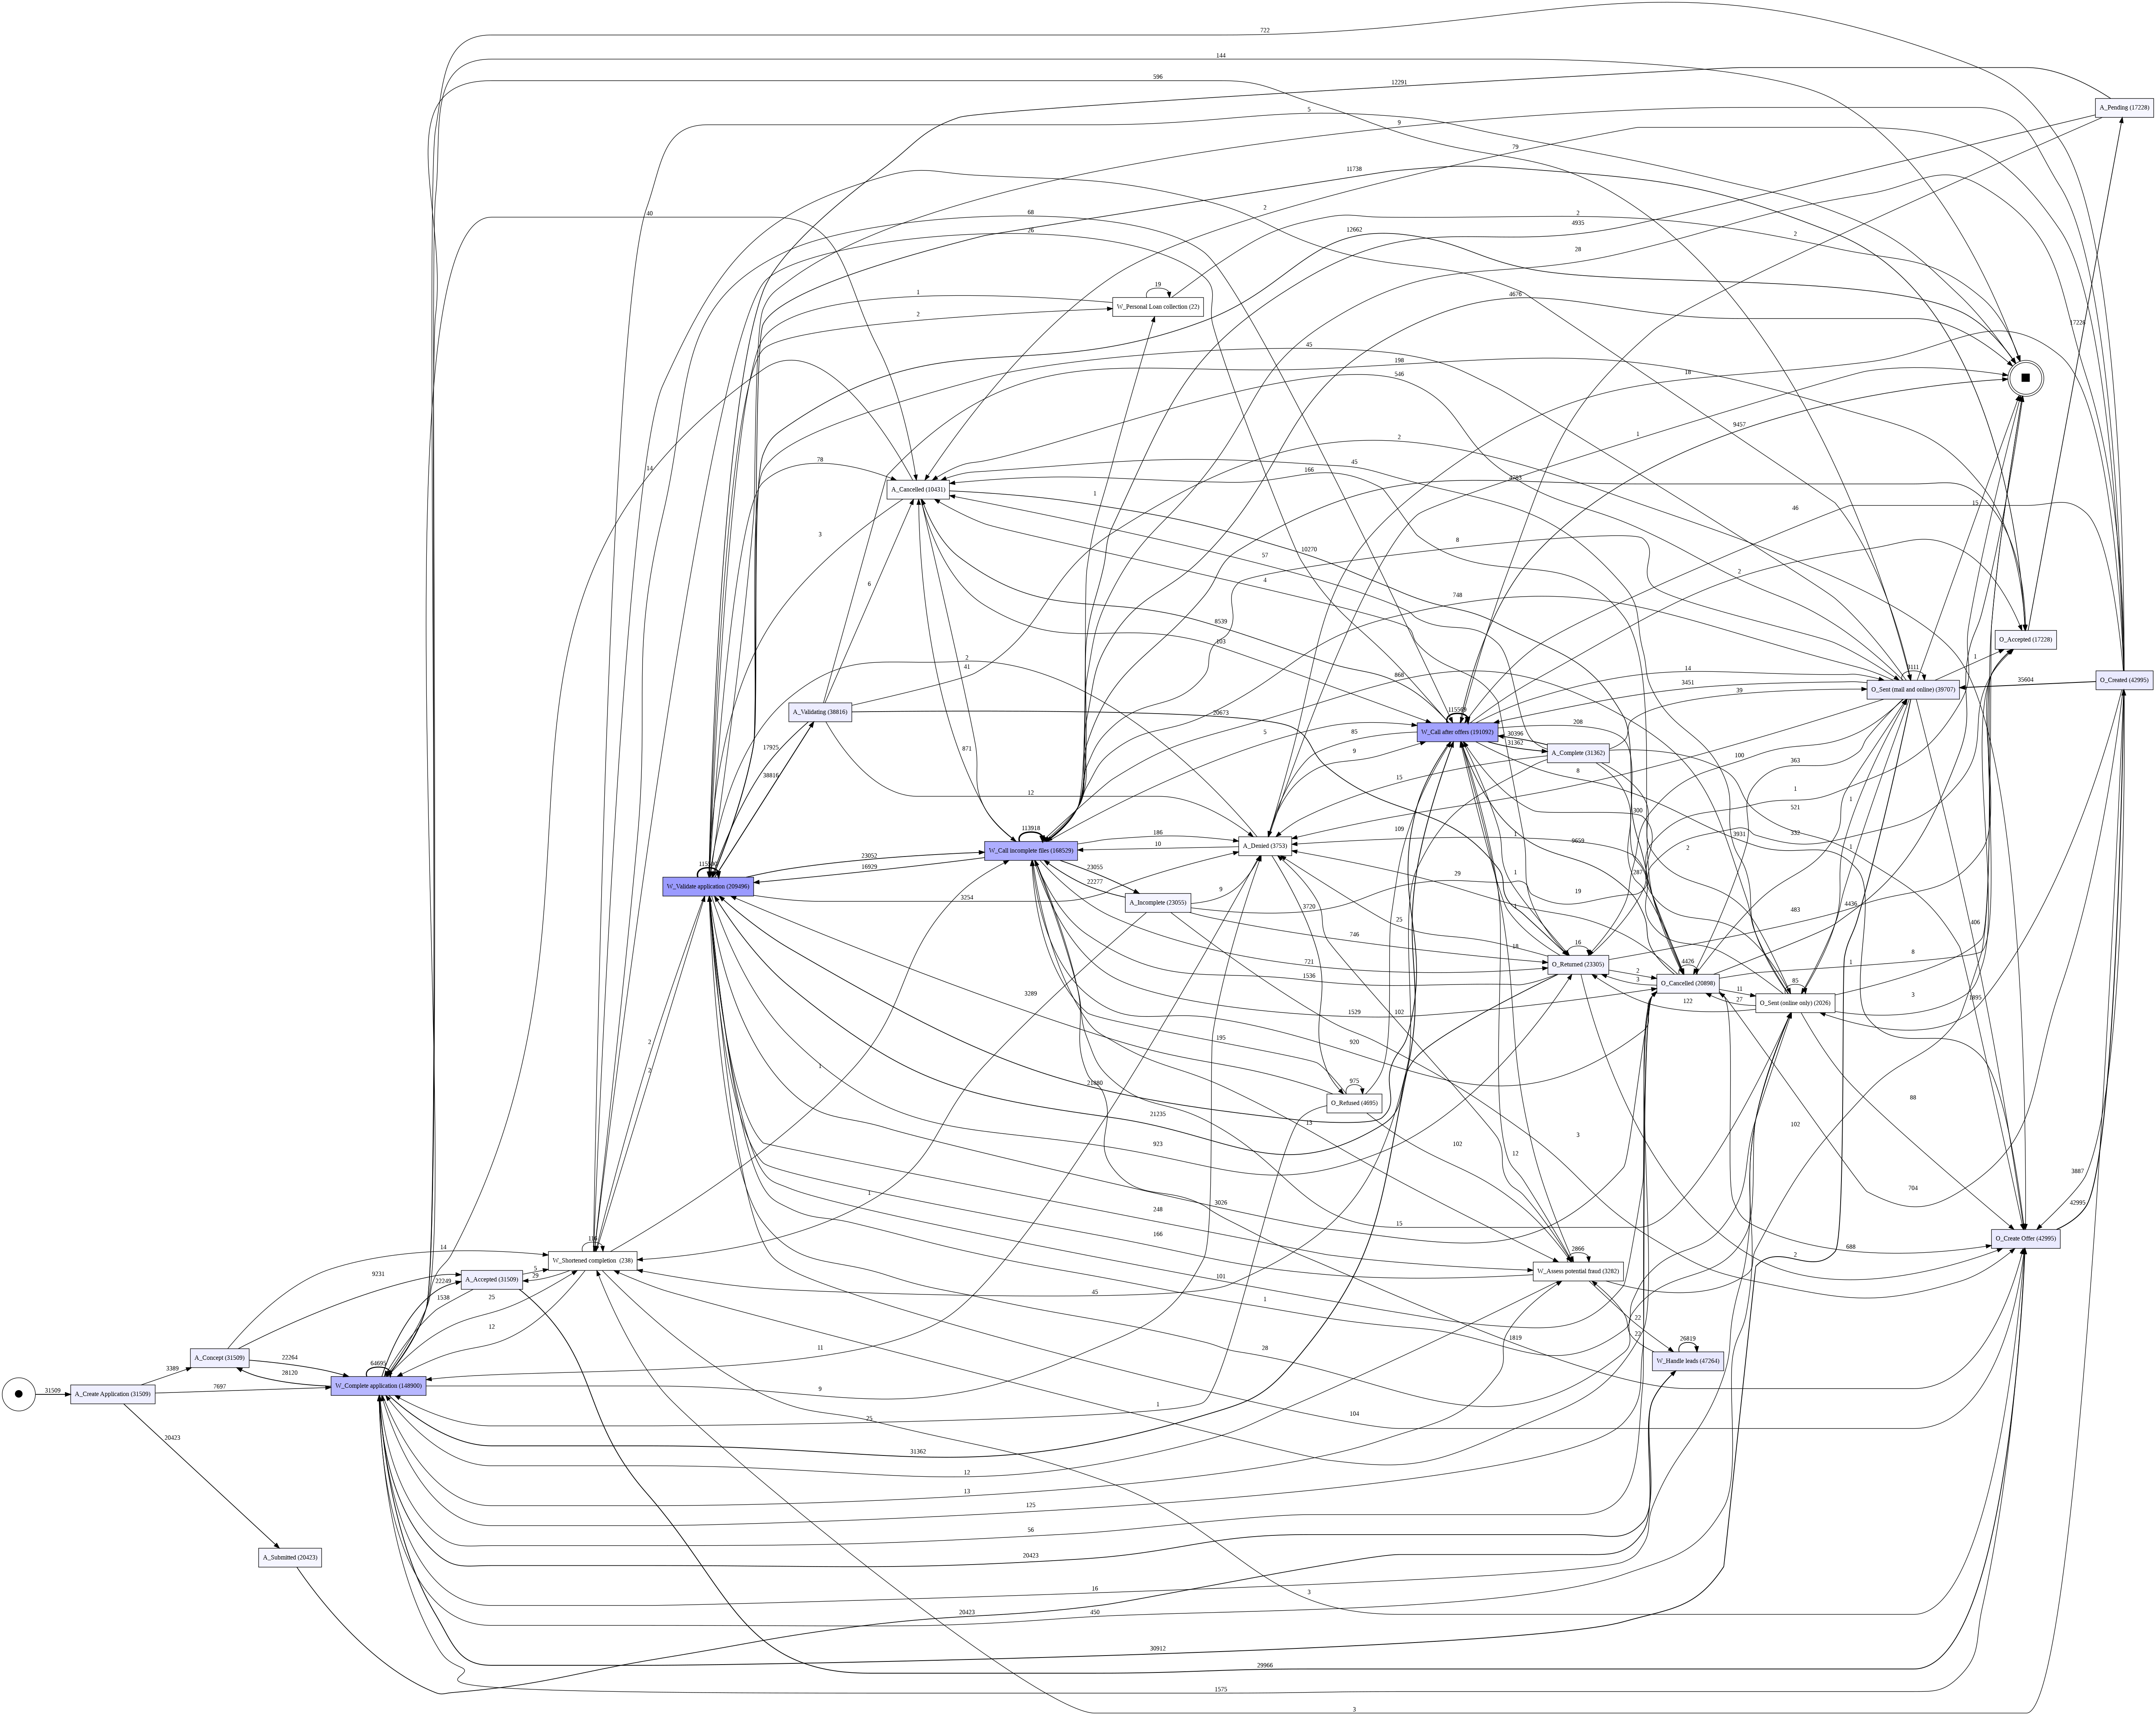

In [9]:
# discover_dfg returns (dfg, start_activities, end_activities)
dfg, start_activities, end_activities = pm4py.discover_dfg(log)

# Visualize
from pm4py.visualization.dfg import visualizer as dfg_visualizer
gviz = dfg_visualizer.apply(dfg, log=log, variant=dfg_visualizer.Variants.FREQUENCY, parameters={dfg_visualizer.Variants.FREQUENCY.value.Parameters.START_ACTIVITIES: start_activities, dfg_visualizer.Variants.FREQUENCY.value.Parameters.END_ACTIVITIES: end_activities})
dfg_visualizer.view(gviz)

--- Visualizing Cluster 1 (Variant Frequency: 1056 traces) ---


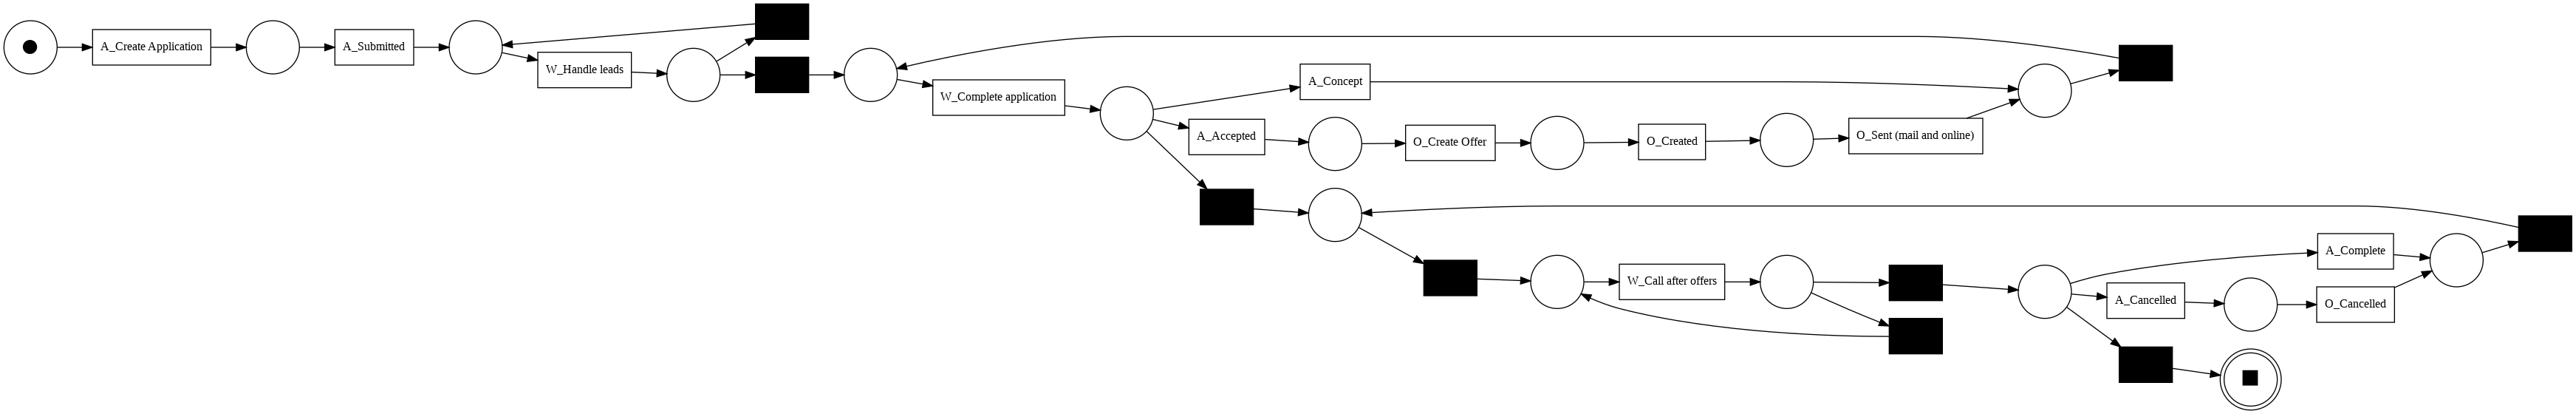

--- Visualizing Cluster 2 (Variant Frequency: 1021 traces) ---


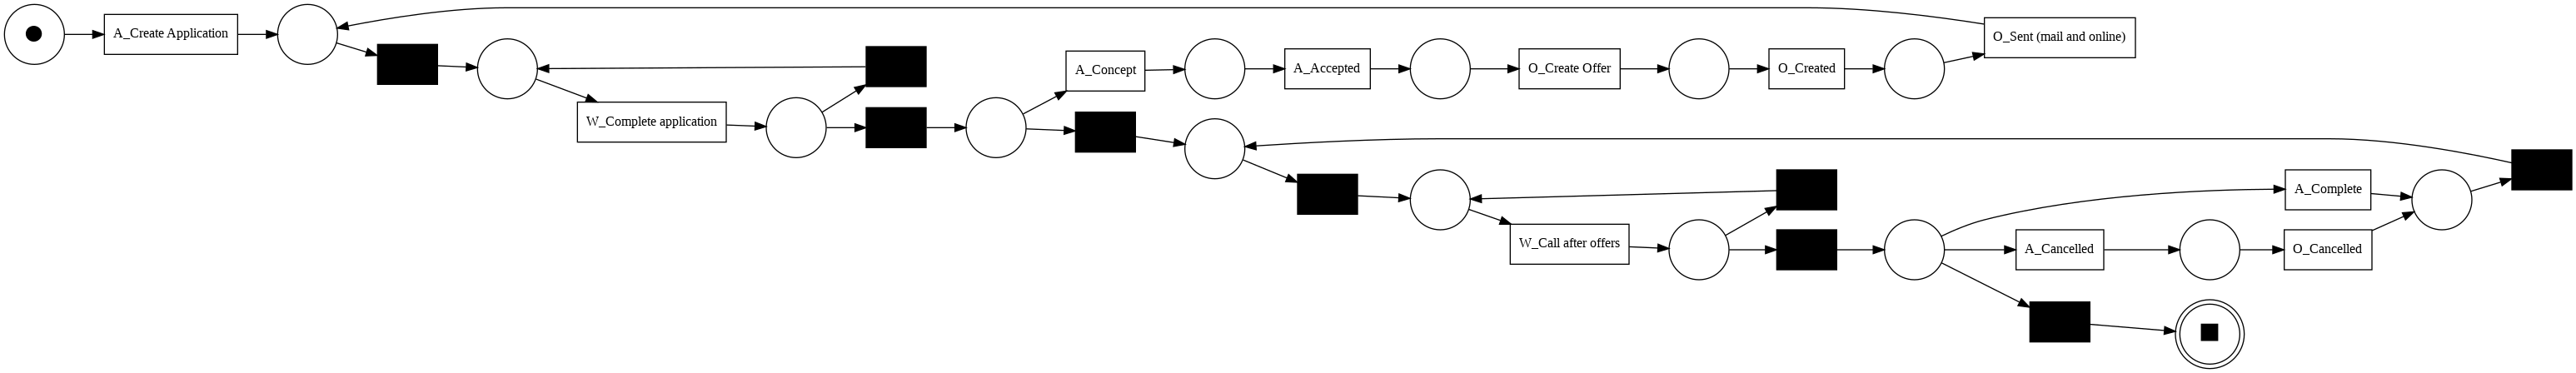

--- Visualizing Cluster 3 (Variant Frequency: 734 traces) ---


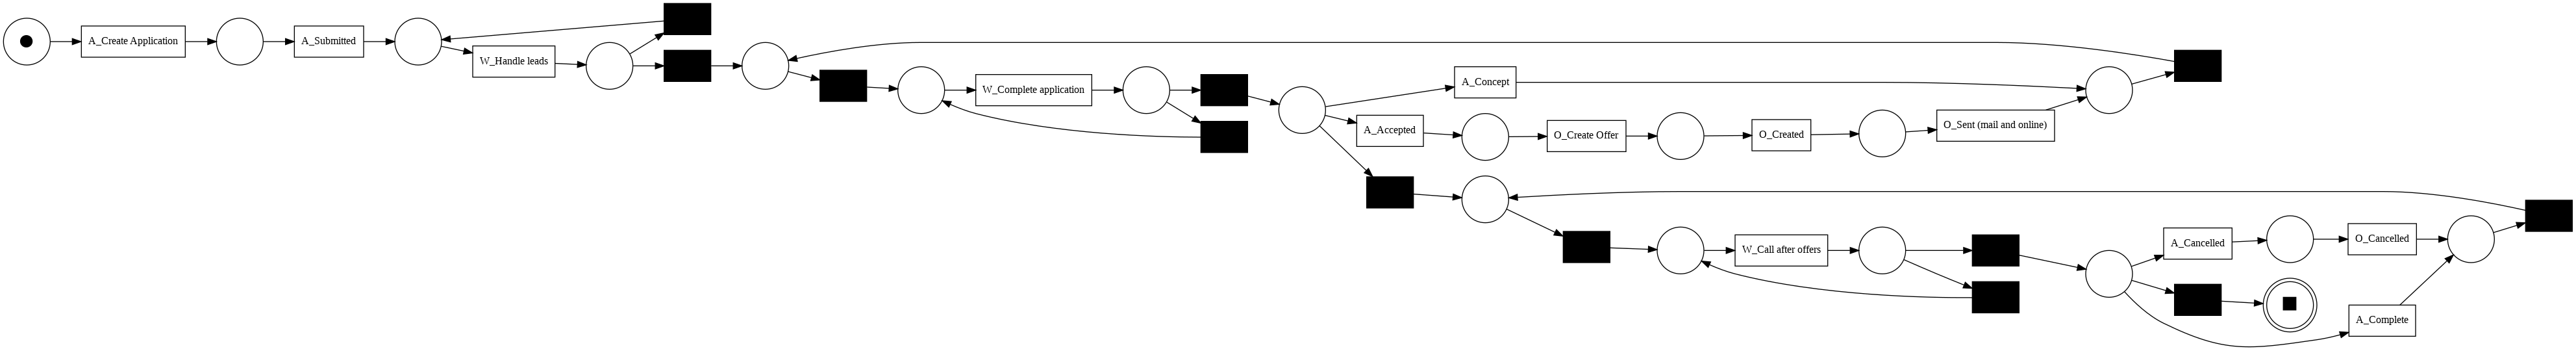

--- Visualizing Cluster 4 (Variant Frequency: 451 traces) ---


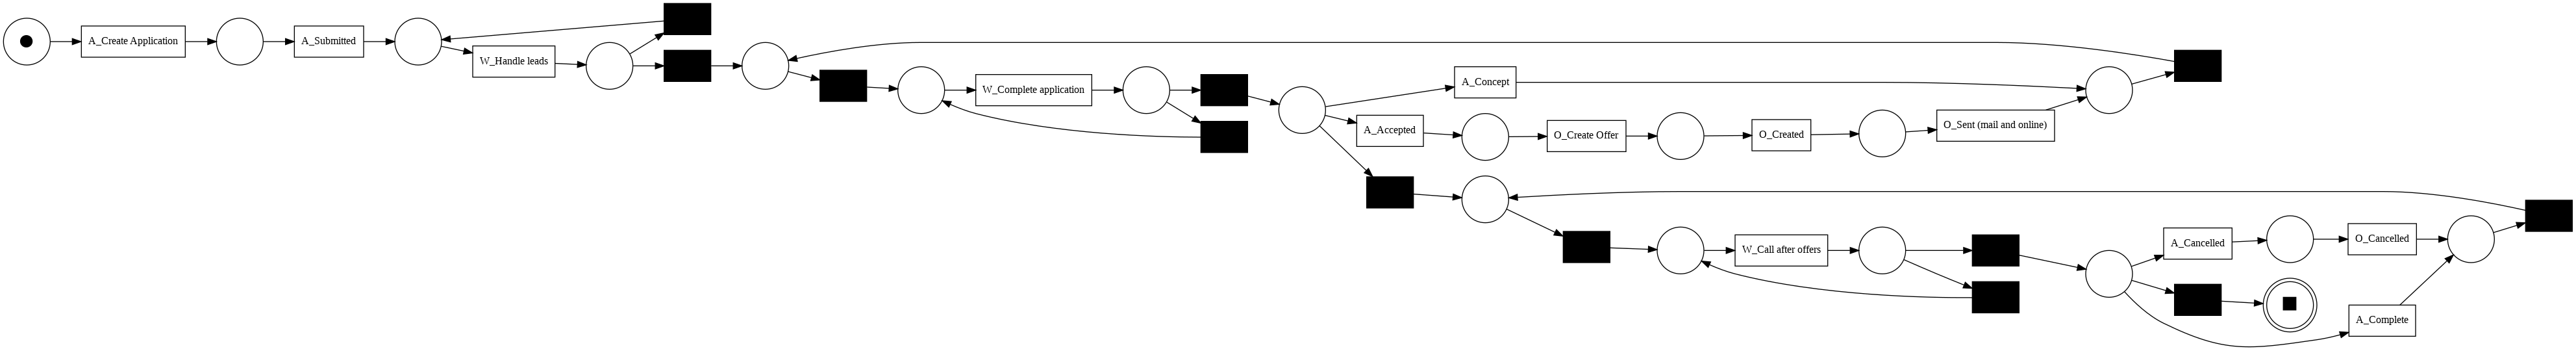

--- Visualizing Cluster 5 (Variant Frequency: 332 traces) ---


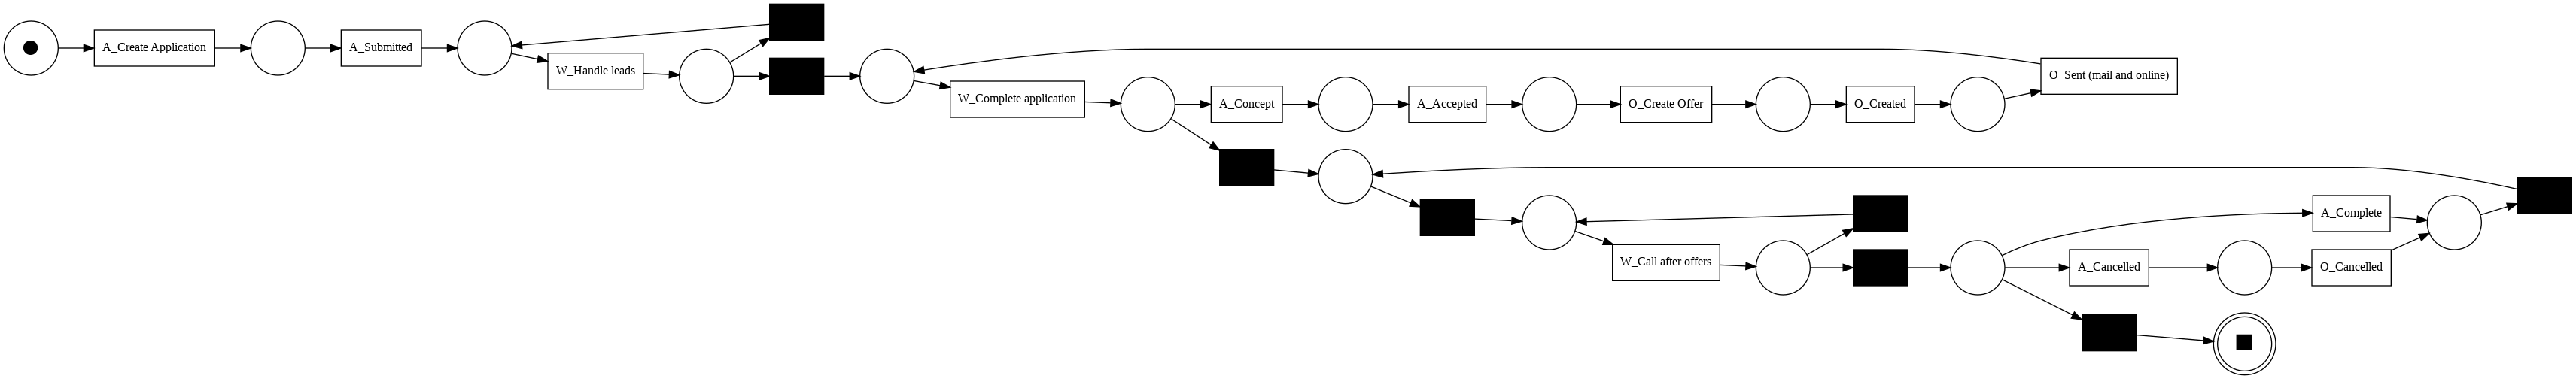

--- Visualizing Cluster 6 (Variant Frequency: 298 traces) ---


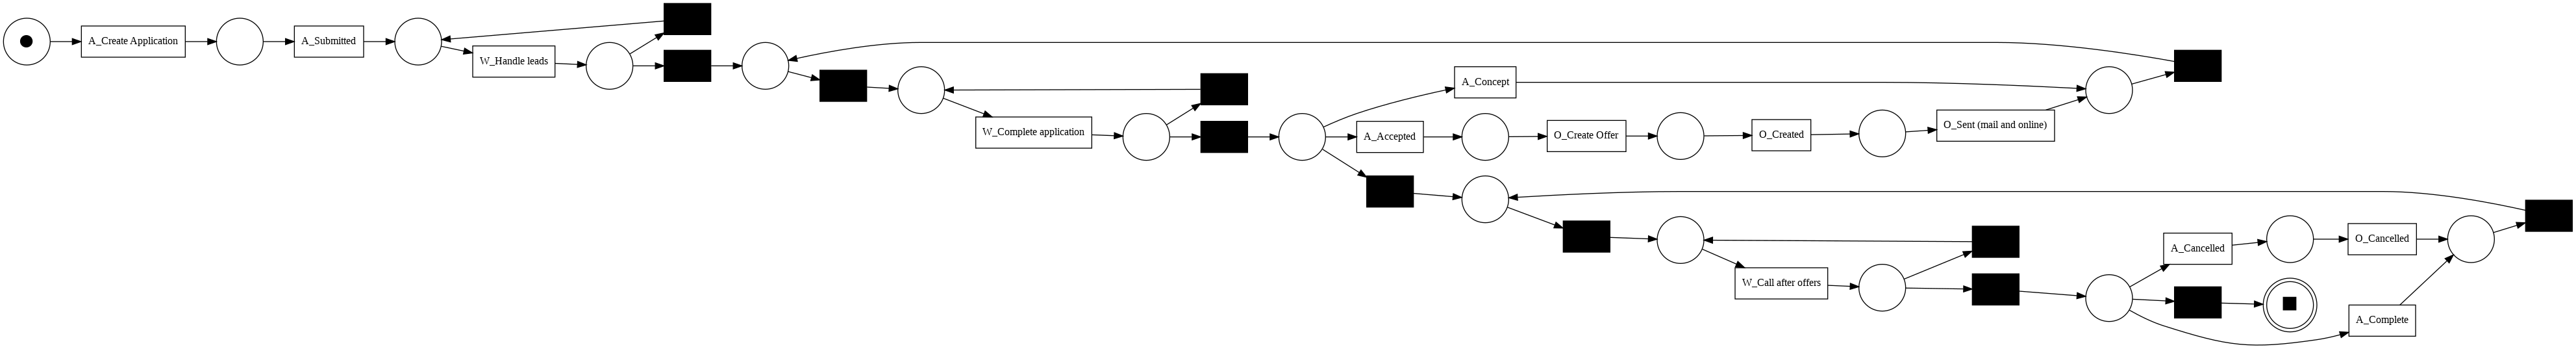

--- Visualizing Cluster 7 (Variant Frequency: 278 traces) ---


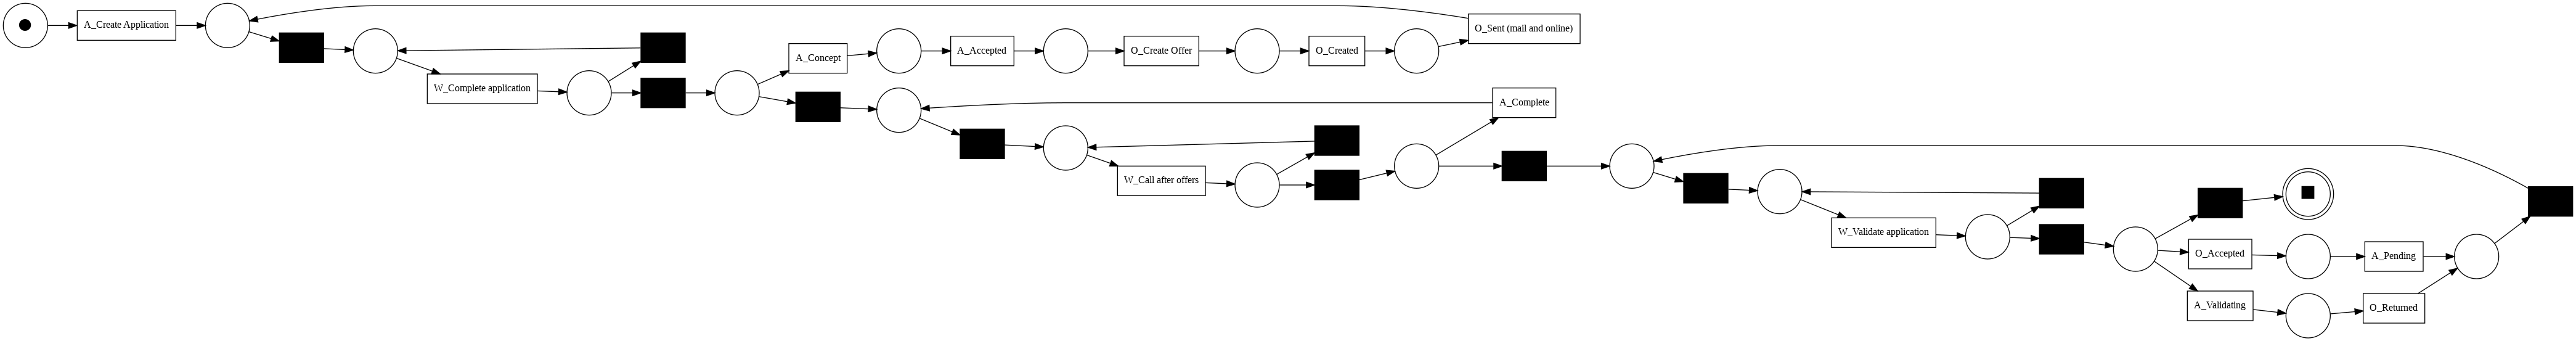

--- Visualizing Cluster 8 (Variant Frequency: 244 traces) ---


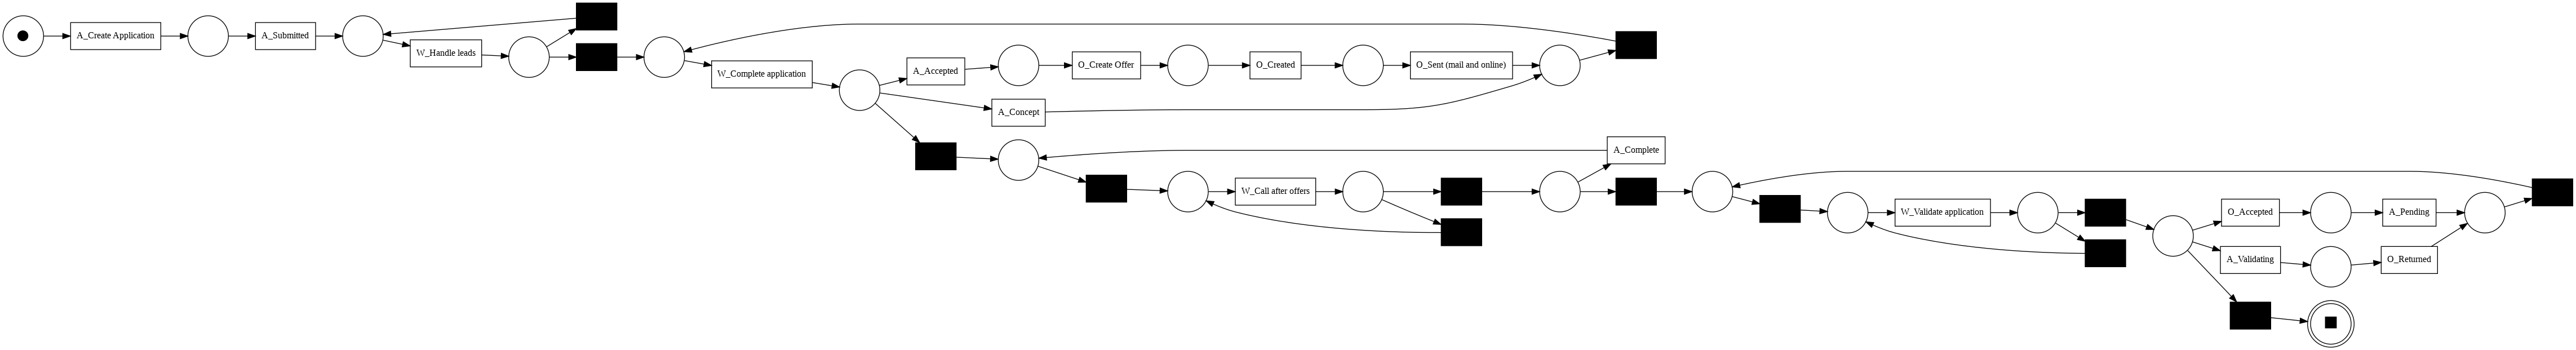

--- Visualizing Cluster 9 (Variant Frequency: 212 traces) ---


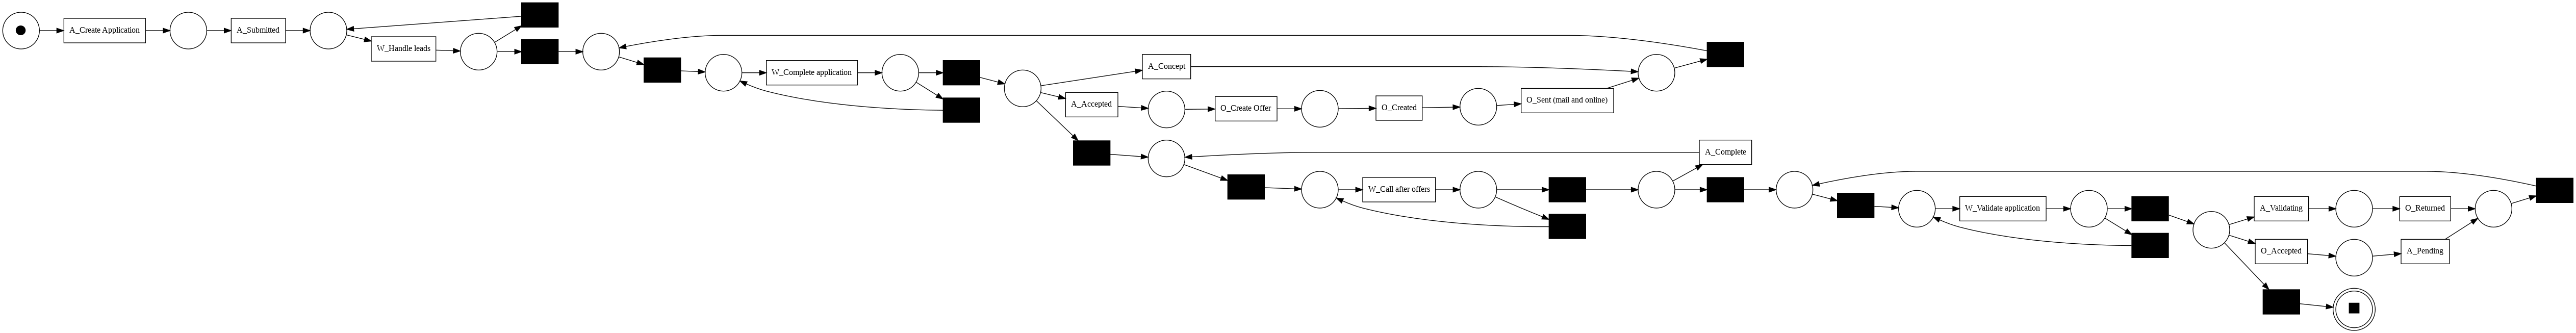

--- Visualizing Cluster 10 (Variant Frequency: 204 traces) ---


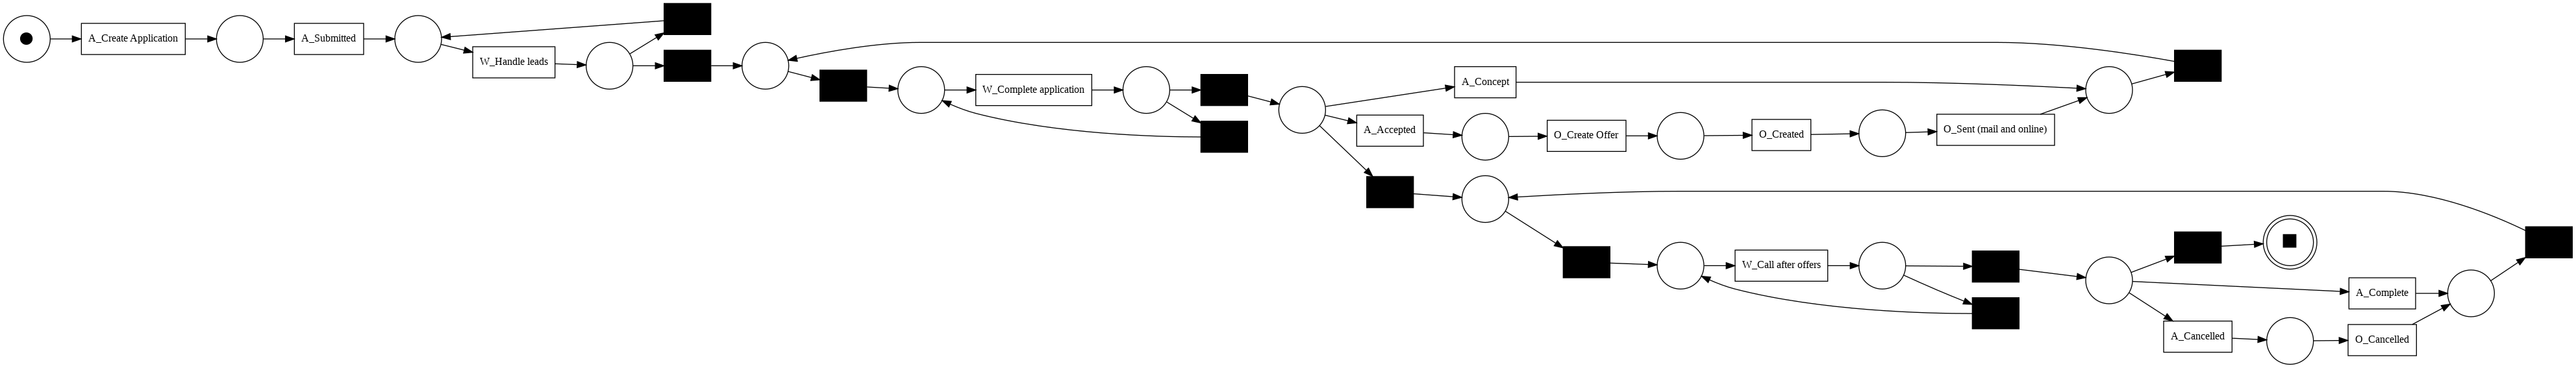

In [10]:
import pm4py
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

# Since the specific clustering module was not found, we will use variant-based filtering
# to group the most frequent process patterns as clusters.
from pm4py.algo.filtering.log.variants import variants_filter

# Get variants
variants = variants_filter.get_variants(log)
# Sort variants by frequency
ordered_variants = sorted(variants.items(), key=lambda x: len(x[1]), reverse=True)

# We will treat the top 10 most frequent variants as our 'clusters'
no_clusters = 10

for i in range(no_clusters):
    variant_tuple, cluster_traces = ordered_variants[i]
    # Convert the list of traces back to a Log object
    cluster_log = pm4py.objects.log.obj.EventLog(cluster_traces)

    print(f"--- Visualizing Cluster {i+1} (Variant Frequency: {len(cluster_log)} traces) ---")

    # Discover a Petri net for this specific variant cluster
    net, im, fm = pm4py.discover_petri_net_inductive(cluster_log)

    # Show the model
    gviz = pn_visualizer.apply(net, im, fm)
    pn_visualizer.view(gviz)

    # Save the model
    pn_visualizer.save(gviz, f"cluster_{i+1}_model.png")